# Download catalog files

In [2]:
import os
if not os.path.exists("dja_msaexp_emission_lines_v4.4.csv"):
    ! wget https://zenodo.org/records/15472354/files/dja_msaexp_emission_lines_v4.4.csv.gz
    #decompress the file
    ! gunzip dja_msaexp_emission_lines_v4.4.csv.gz
if not os.path.exists("dja_msaexp_emission_lines_v4.4.columns.csv"):   
    ! wget https://zenodo.org/records/15472354/files/dja_msaexp_emission_lines_v4.4.columns.csv


In [3]:
import pandas as pd
df = pd.read_csv("dja_msaexp_emission_lines_v4.4.csv")
df.head()

/tmp/ipykernel_544685/2695337296.py:2: DtypeWarning: Columns (321,324,330,360,361) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dja_msaexp_emission_lines_v4.4.csv")


,file,srcid,ra,dec,grating,filter,effexptm,nfiles,dataset,msamet,...,beta_wlo,beta_whi,beta_nmad,dla_npix,dla_value,dla_unc,beta_cov_00,beta_cov_01,beta_cov_10,beta_cov_11
0,abell2744-castellano1-v4_prism-clear_3073_1400...,14008,3.497359,-30.358230,PRISM,CLEAR,2188.333,6,jw03073010001_03101_00001_nrs1_clear_prism_raw...,jw03073010001_01_msa.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,abell2744-castellano1-v4_prism-clear_3073_1403...,14033,3.493713,-30.360167,PRISM,CLEAR,2188.333,12,jw03073011001_03101_00001_nrs1_clear_prism_raw...,jw03073011001_01_msa.fits,...,0.141974,0.257962,0.863961,10.0,164.297141,48.081386,0.169414,-0.000296,-0.000296,0.000002
2,abell2744-castellano1-v4_prism-clear_3073_1413...,14130,3.498384,-30.358731,PRISM,CLEAR,2188.333,6,jw03073011001_03101_00001_nrs2_clear_prism_raw...,jw03073011001_01_msa.fits,...,0.221530,0.257772,1.150327,0.0,-1.000000,-1.000000,0.465769,-0.060752,-0.060752,0.008047
3,abell2744-castellano1-v4_prism-clear_3073_1418...,14182,3.497377,-30.359286,PRISM,CLEAR,2188.333,6,jw03073011001_03101_00001_nrs1_clear_prism_raw...,jw03073011001_01_msa.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,abell2744-castellano1-v4_prism-clear_3073_1426...,14269,3.497626,-30.359020,PRISM,CLEAR,2188.333,6,jw03073010001_03101_00001_nrs2_clear_prism_raw...,jw03073010001_01_msa.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Unique filters: ['CLEAR' 'F100LP' 'F170LP' 'F290LP' 'F070LP']
Unique gratings: ['PRISM' 'G140H' 'G235H' 'G395H' 'G140M' 'G235M' 'G395M']


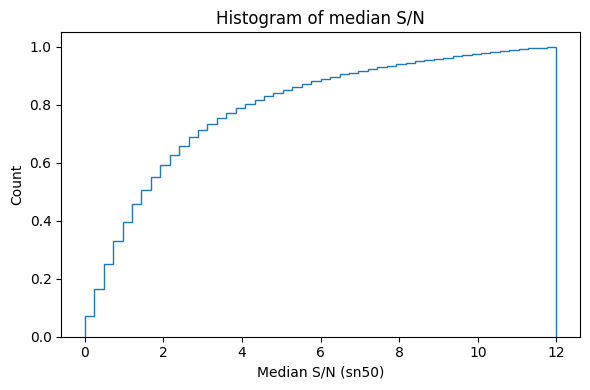

length of low res spectra: 20458
length of low res spectra with grade >= 2 18102
length of mid res spectra: 4123
length of mid res spectra with grade >= 2 3959
length of high res spectra: 124
length of high res spectra with grade >= 2 117


In [28]:
import matplotlib.pyplot as plt
import numpy as np

#unique filters and gratings
print("Unique filters:", df['filter'].unique())
print("Unique gratings:", df['grating'].unique())

mask_main = df['grade'].isin([1,2,3]) & (df['obs_365_frac'] > 0.5) #& (df["wmin"] < 1.3) & (df["wmax"] > 1.7)
mask_low_res = mask_main  & df['grating'].isin(['PRISM'])
mask_mid_res = mask_main  & (df['grating'].isin(['G140M', 'G235M', 'G395M']))
mask_high_res = mask_main & (df['grating'].isin(['G140H', 'G235H', 'G395H']))

sn_median = df["sn50"][mask_main].dropna()

plt.figure(figsize=(6,4))
plt.hist(sn_median, bins=50, histtype="step", color="C0", range=(0, 12), cumulative=True, density=True)
plt.xlabel("Median S/N (sn50)")
plt.ylabel("Count")
plt.title("Histogram of median S/N")
plt.tight_layout()
plt.show()

print("length of low res spectra:", mask_low_res.sum())
print('length of low res spectra with grade >= 2', (mask_low_res & (df['grade'] >= 2)).sum())
print("length of mid res spectra:", mask_mid_res.sum())
print('length of mid res spectra with grade >= 2', (mask_mid_res & (df['grade'] >= 2)).sum())
print("length of high res spectra:", mask_high_res.sum())
print('length of high res spectra with grade >= 2', (mask_high_res & (df['grade'] >= 2)).sum())

In [ ]:

#save csv per resolution
df[mask_low_res].to_csv("jda_low_res.csv", index=False)
df[mask_mid_res].to_csv("jda_mid_res.csv", index=False)
df[mask_high_res].to_csv("jda_high_res.csv", index=False)

In [5]:
#run download spectra
!python download_spectra_from_csv.py --csv-table 'jda_low_res.csv'  --num-workers 20
!python download_spectra_from_csv.py --csv-table 'jda_mid_res.csv'  --num-workers 20
!python download_spectra_from_csv.py --csv-table 'jda_high_res.csv' --num-workers 20

Input rows: 20458
Unique files: 20458
Workers: 20
Download dir: download
--- Summary ---
downloaded: 0
exists:     19513
failed:     945
Input rows: 4123
Unique files: 4123
Workers: 20
Download dir: download
--- Summary ---
downloaded: 0
exists:     4123
failed:     0
Input rows: 124
Unique files: 124
Workers: 20
Download dir: download
--- Summary ---
downloaded: 0
exists:     124
failed:     0


In [25]:
#make separate .h5 files
!python export_jda_spectrum.py --csv 'jda_low_res.csv'  --num-workers 20 --out 'jda_spectra_low.h5'
!python export_jda_spectrum.py --csv 'jda_mid_res.csv'  --num-workers 20 --out 'jda_spectra_mid.h5'
!python export_jda_spectrum.py --csv 'jda_high_res.csv' --num-workers 20 --out 'jda_spectra_high.h5'

[info] 20458 rows  from jda_low_res.csv
[info] spectra dir : /home/yacheng/ssl_outthere/images/JDA/download
[info] output      : /home/yacheng/ssl_outthere/images/JDA/jda_spectra_low.h5
/home/yacheng/ssl_outthere/.venv/lib64/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
processing: 100%|████████████████████████▉| 20456/20458 [06:35<00:00, 51.67it/s]
[stats] total rows : 20458
        ok         : 19513
        missing    : 945
        corrupted  : 0
        skipped    : 945  (4.6 %)
[ok] wrote 19513 spectra -> jda_spectra_low.h5
[info] 4123 rows  from jda_mid_res.csv
[info] spectra dir : /home/yacheng/ssl_outthere/images/JDA/download
[info] output      : /home/yacheng/ssl_outthere/images/JDA/jda_spectra_mid.h5
/home/yacheng/ssl_outthere/.venv/lib64/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: '

Resolution: low, shape of flux: (19513, 56), number of spectra: 19513, wavelength range: 1.0035481452941895 - 1.9908100366592407


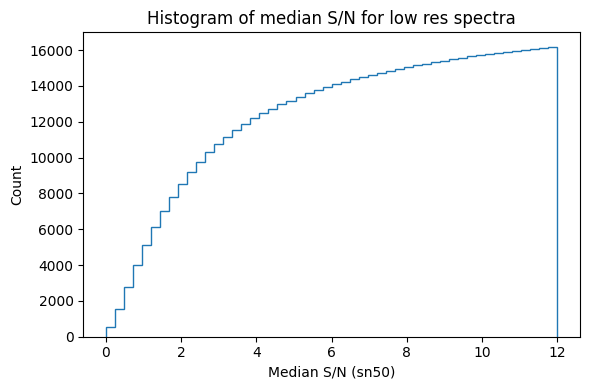

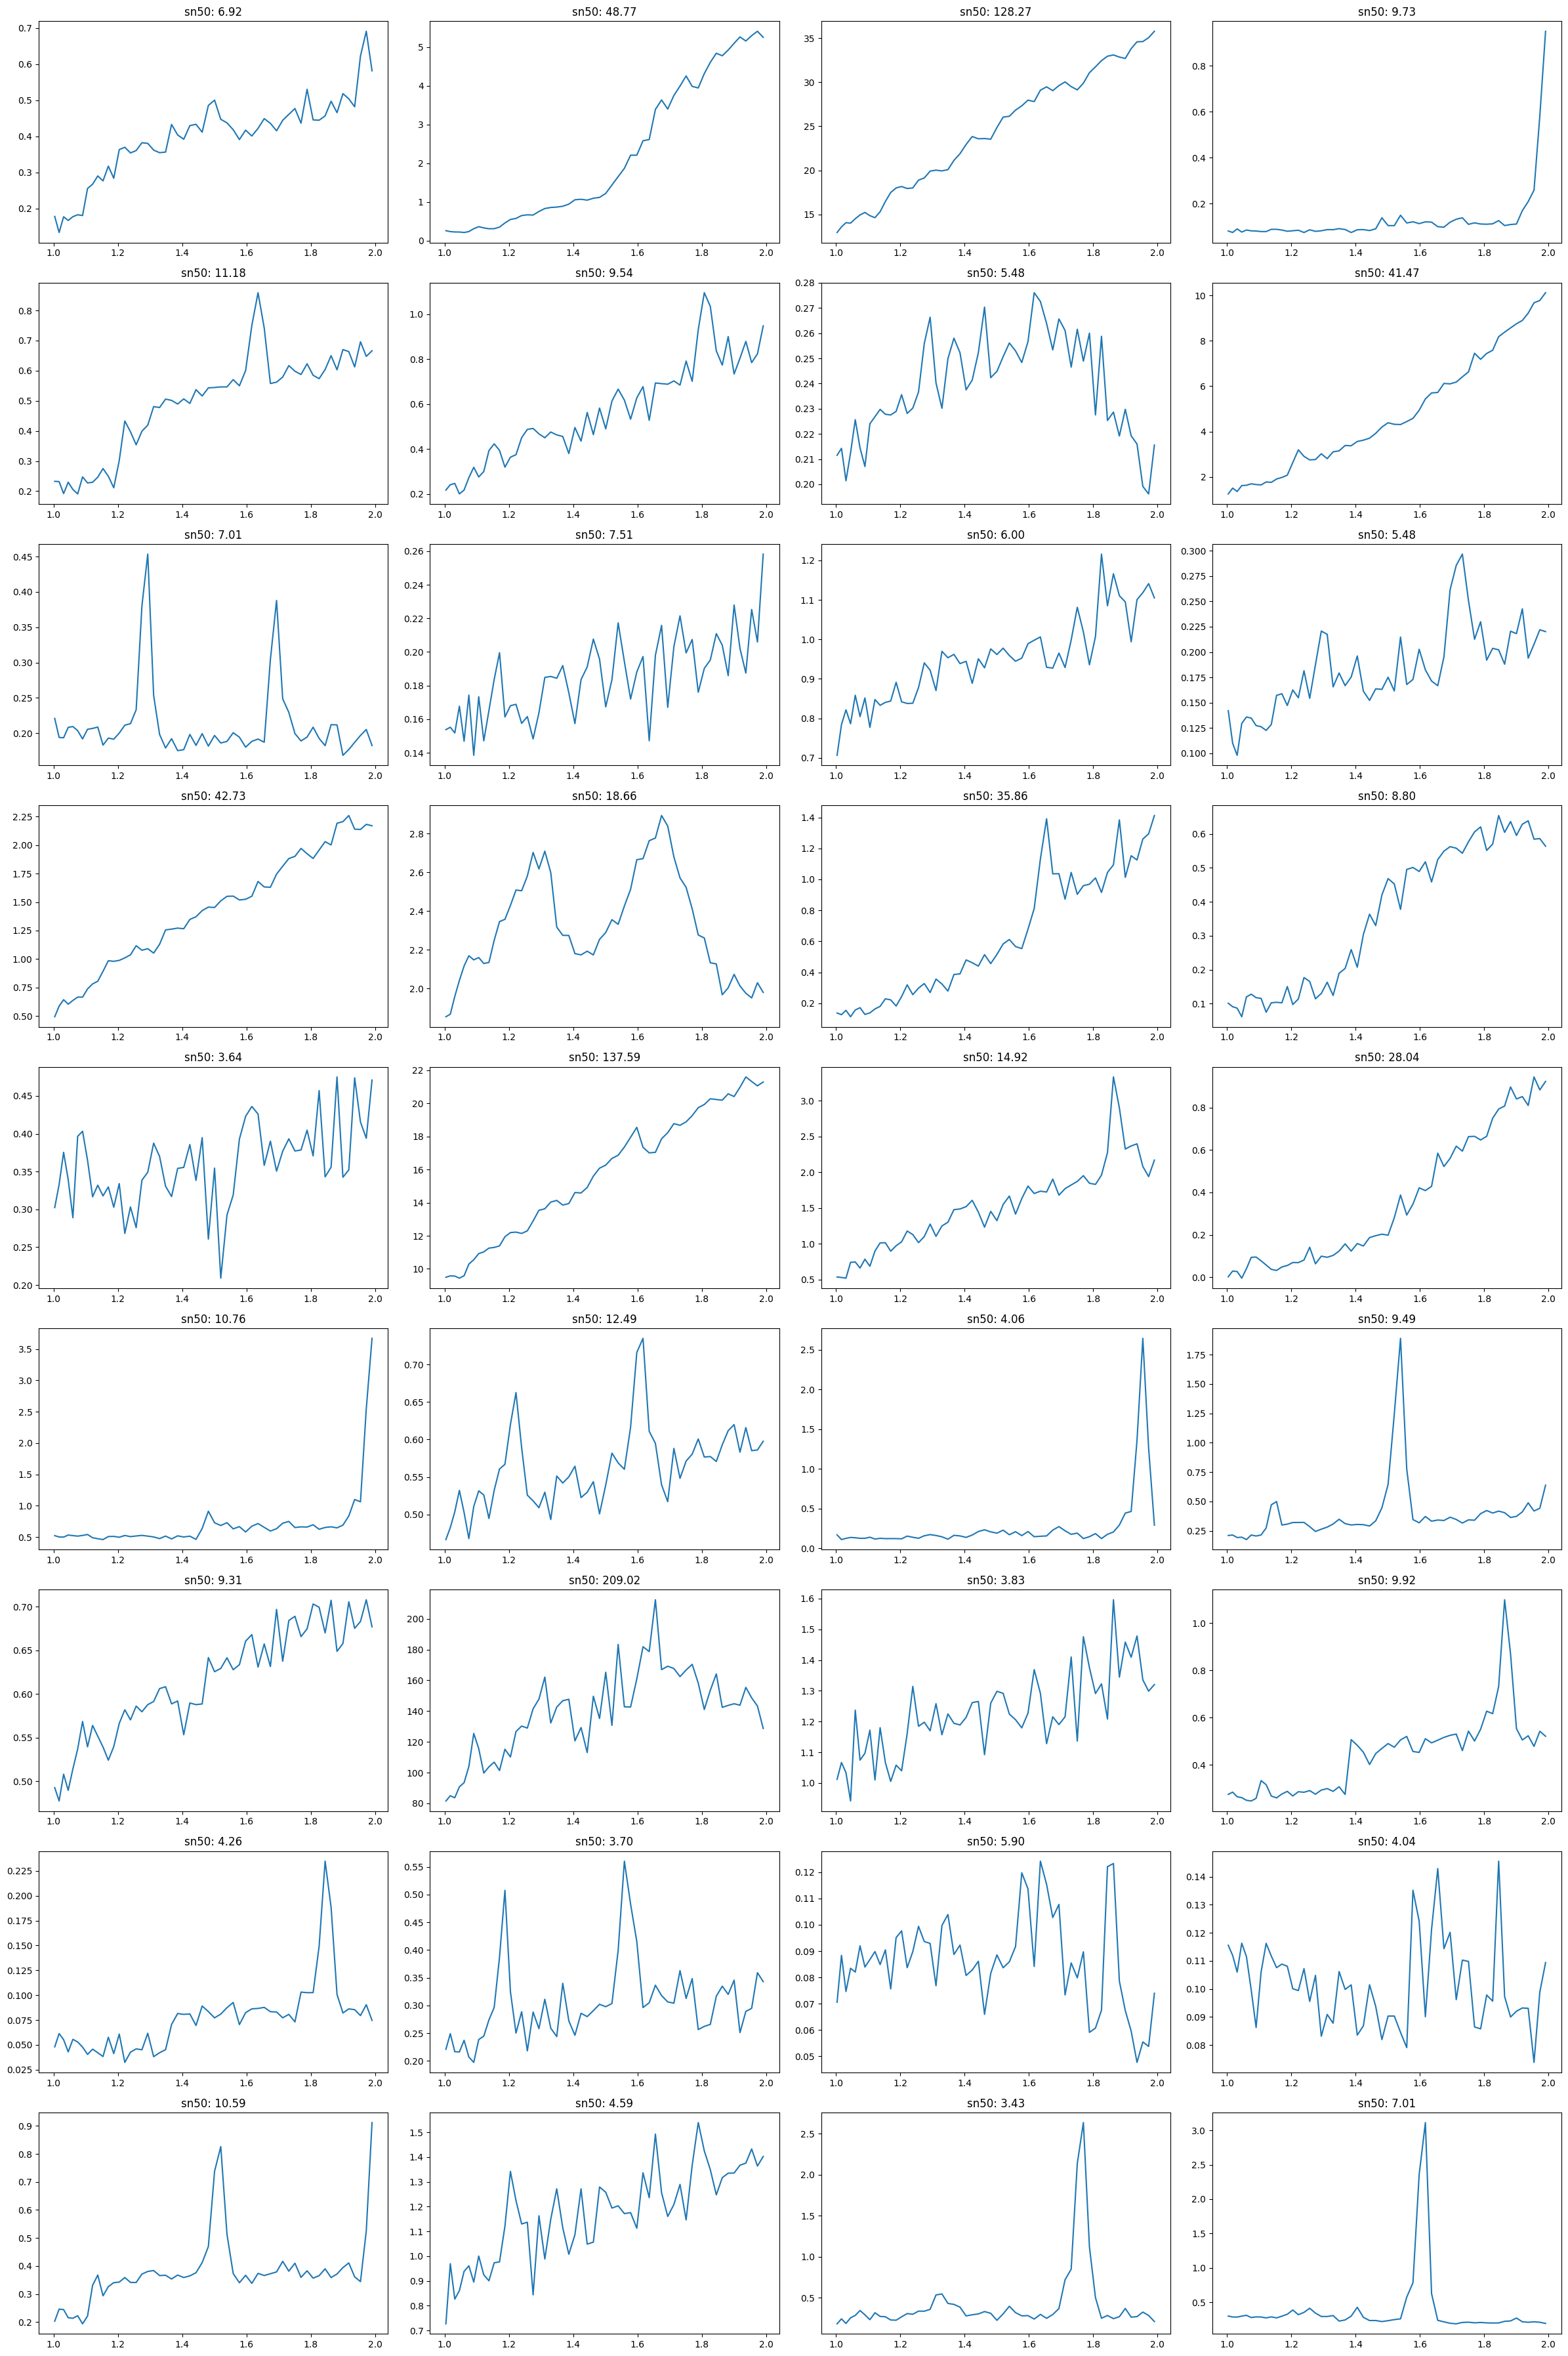

Resolution: mid, shape of flux: (4088, 1666), number of spectra: 4088, wavelength range: 1.000599980354309 - 1.9996000528335571


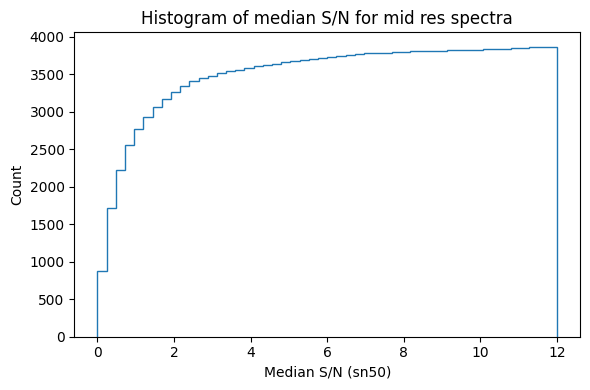

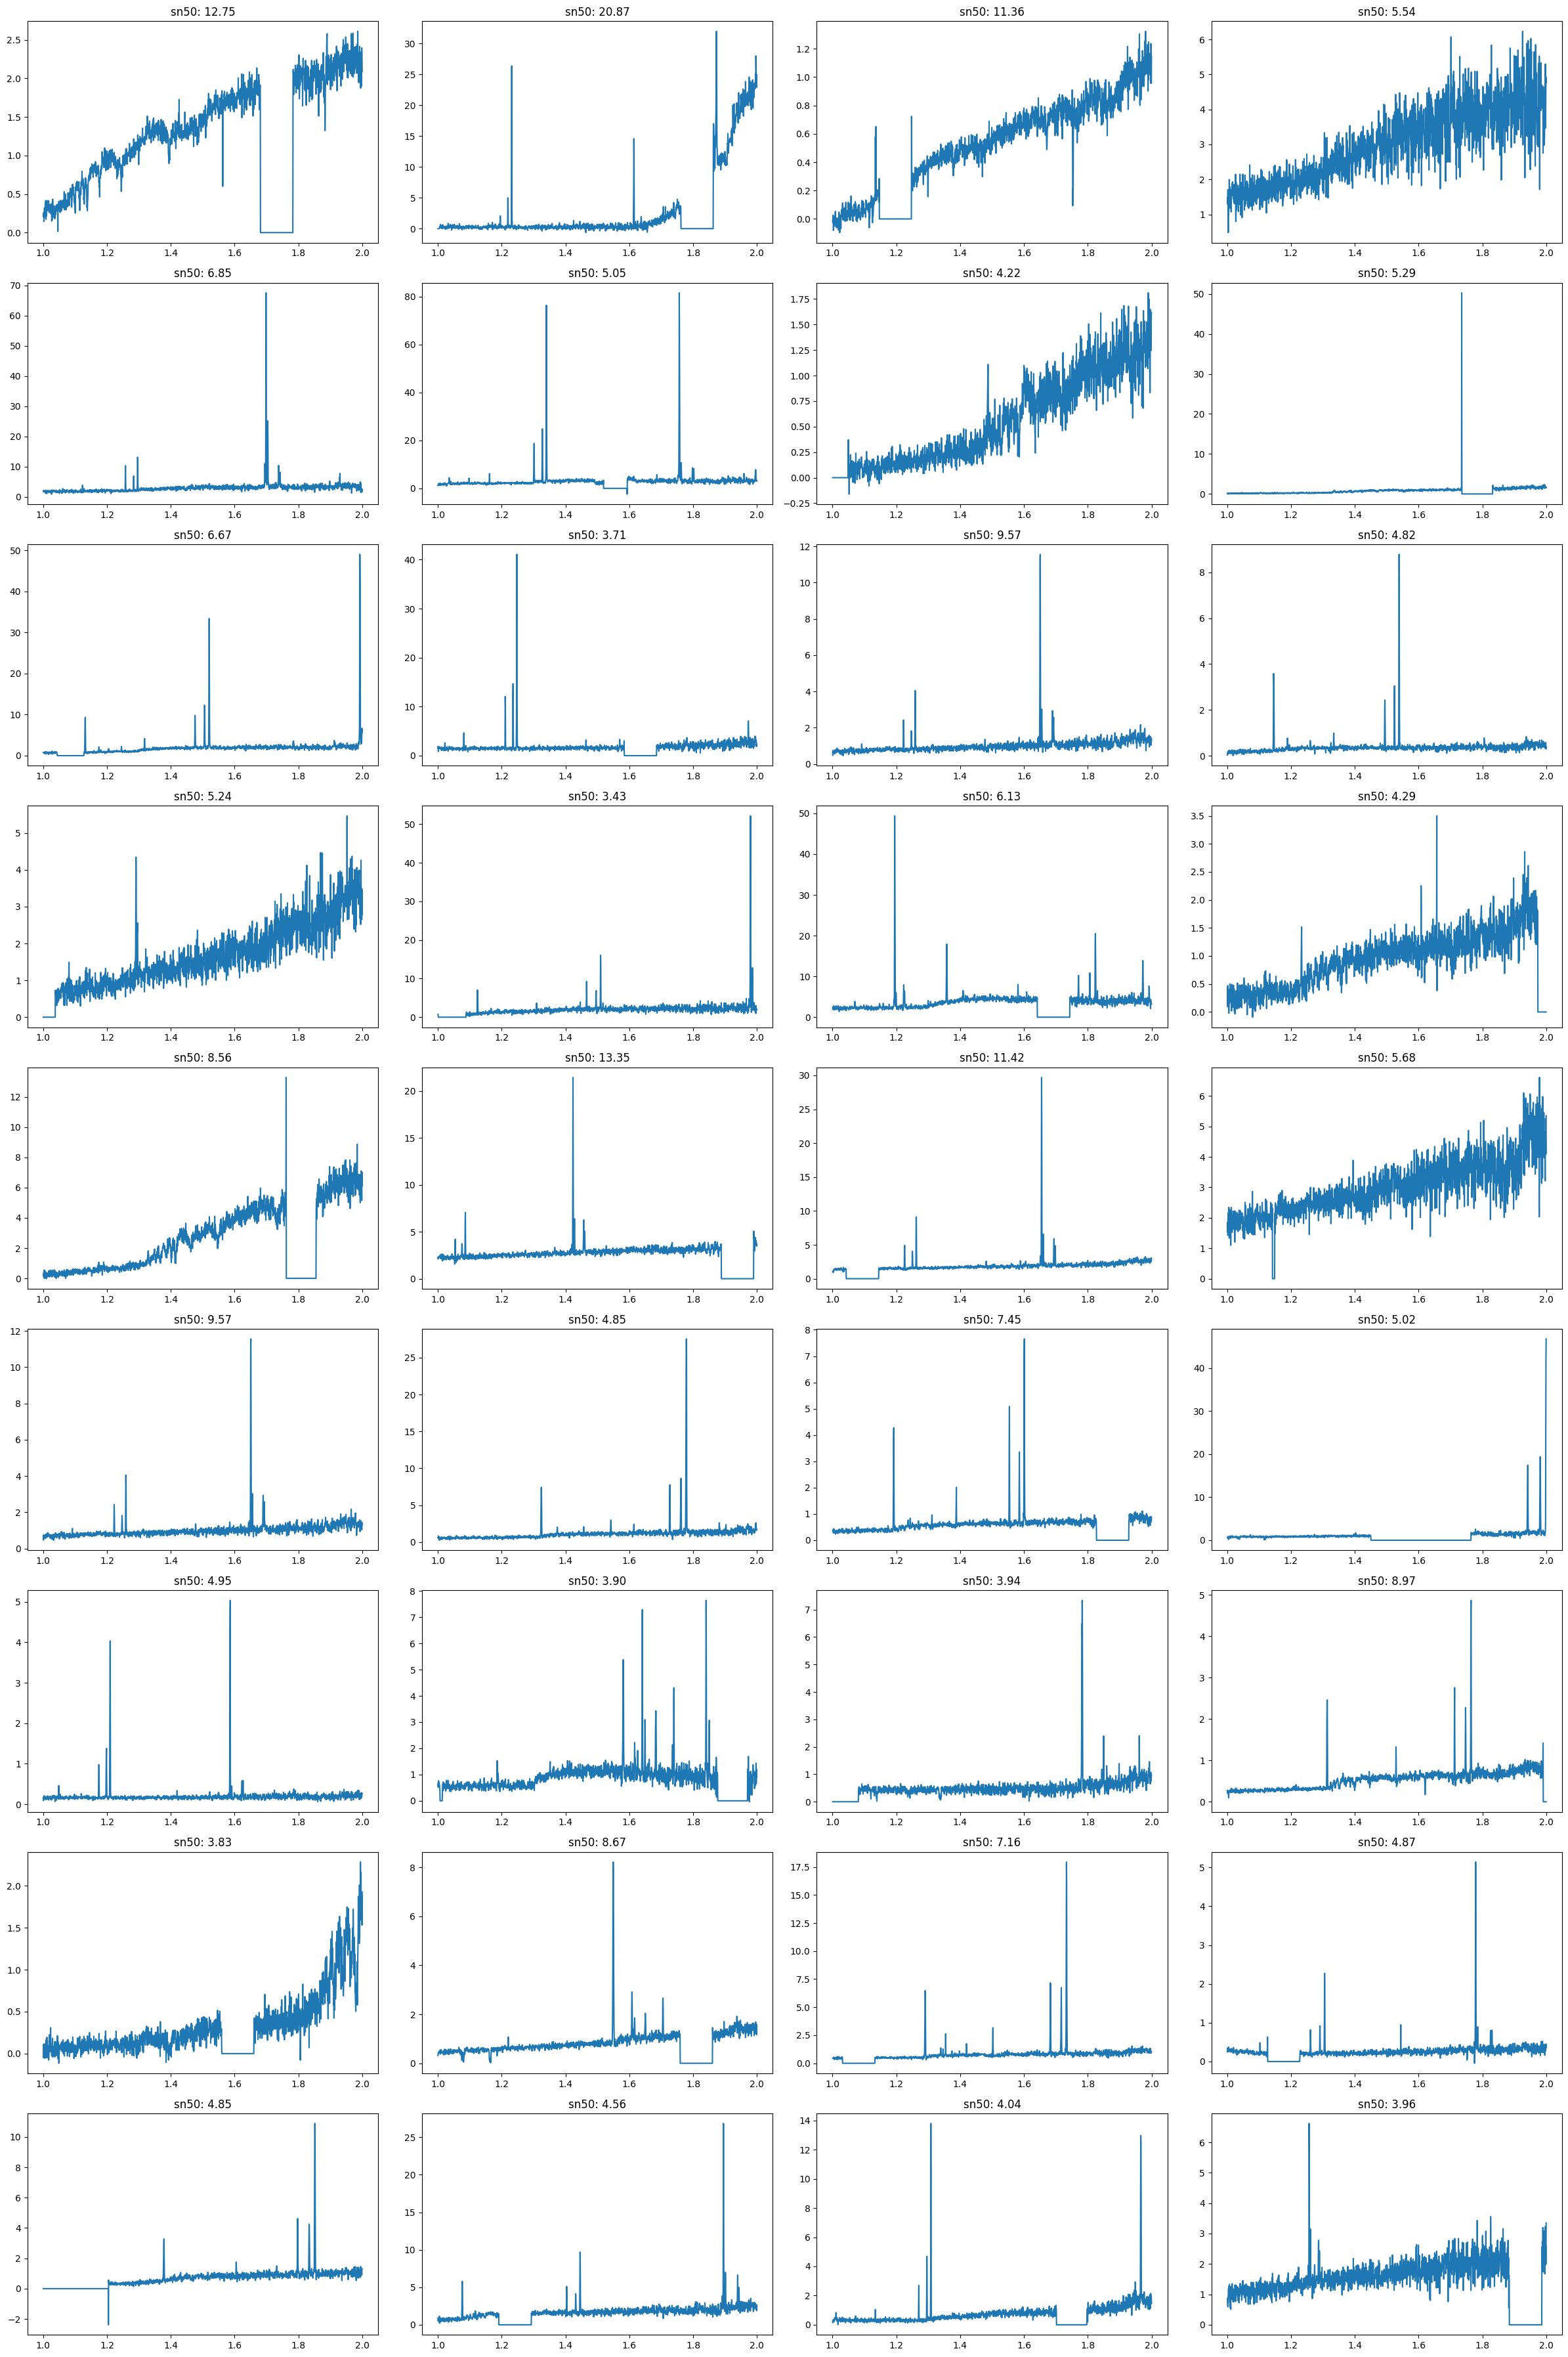

Resolution: high, shape of flux: (124, 3971), number of spectra: 124, wavelength range: 1.0000532865524292 - 1.8999199867248535


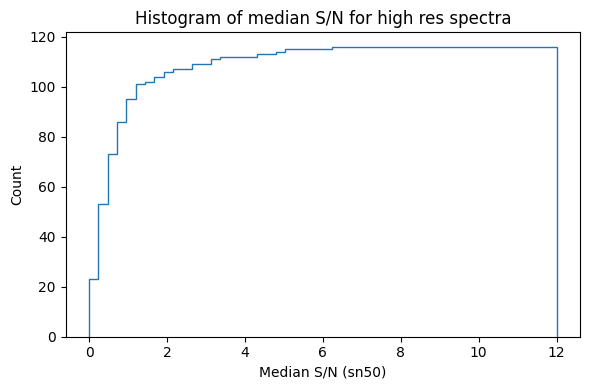

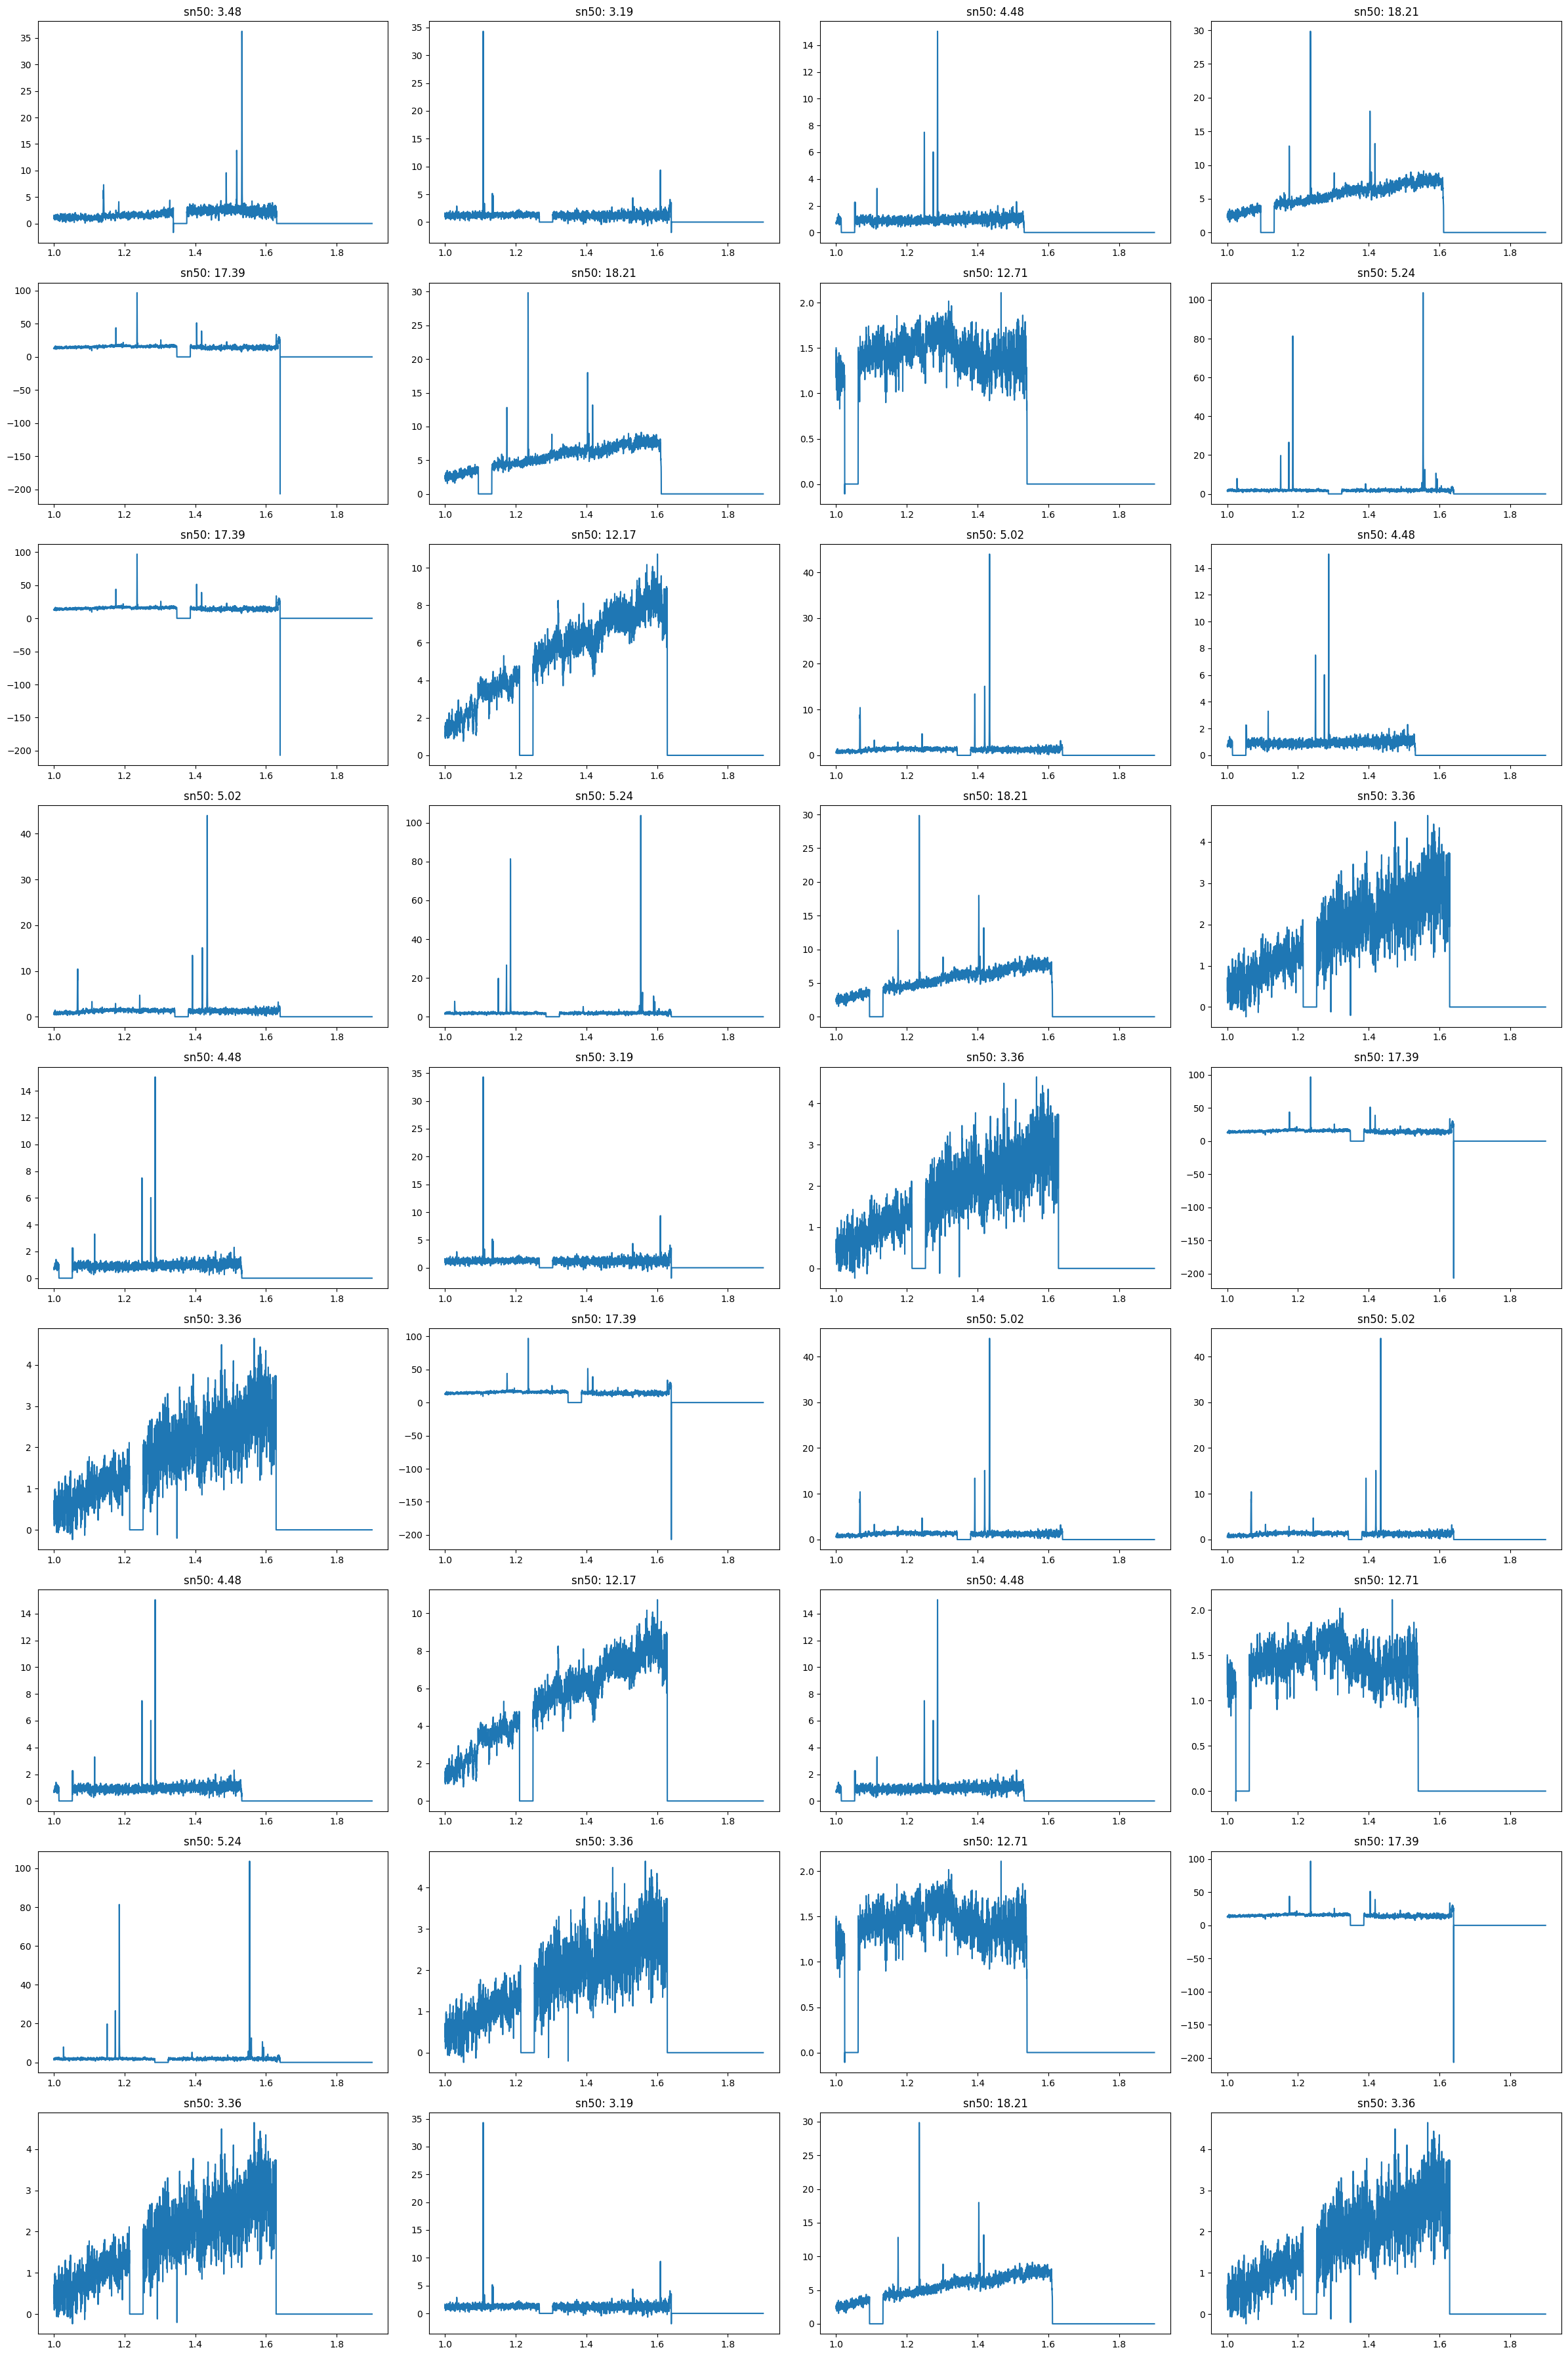

In [23]:
#visualize n examples from each .h5 file
import h5py

n_sample = 36
for res in ["low", "mid", "high"]:
    with h5py.File(f"jda_spectra_{res}.h5", "r") as f:
        print(f"Resolution: {res}, shape of flux: {f['flux'].shape}, number of spectra: {len(f['flux'])}, wavelength range: {f['wave'][0][0]} - {f['wave'][0][-1]}")
        #filter out exazmple spectra with sn50 < 5
        mask_sn = f["sn50"][:] >= 3
        #random n sample index
        idx = np.random.choice(np.where(mask_sn)[0], n_sample)
        
        #plot sn cumulative histogram
        plt.figure(figsize=(6,4))
        plt.hist(f["sn50"][:], bins=50, histtype="step", color="C0", range=(0, 12), cumulative=True, density=False)
        plt.xlabel("Median S/N (sn50)")
        plt.ylabel("Count")
        plt.title(f"Histogram of median S/N for {res} res spectra")
        plt.tight_layout()
        plt.show()
        
        #4 columns of subplots
        rows = (n_sample + 3) // 4
        fig, axes = plt.subplots(rows, 4, figsize=(24, 4*rows))
        for i, index in enumerate(idx):
            ax = axes.flatten()[i]
            wave = f["wave"][index]
            flux = f["flux"][index]
            ax.plot(wave, flux)
            ax.set_title(f"sn50: {f['sn50'][index]:.2f}")
        plt.tight_layout()
        plt.show()
            

Resolution: low, shape of flux: (19513, 56), number of spectra: 19513, wavelength range: 1.0035481452941895 - 1.9908100366592407


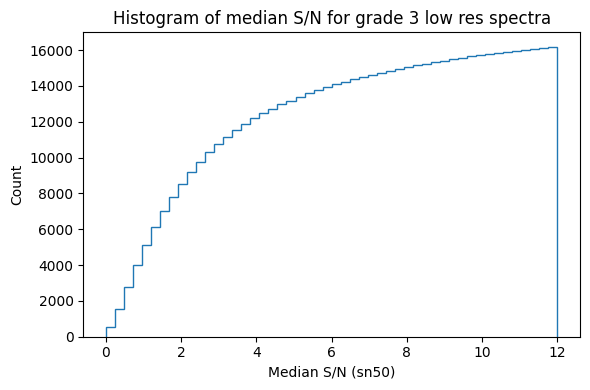

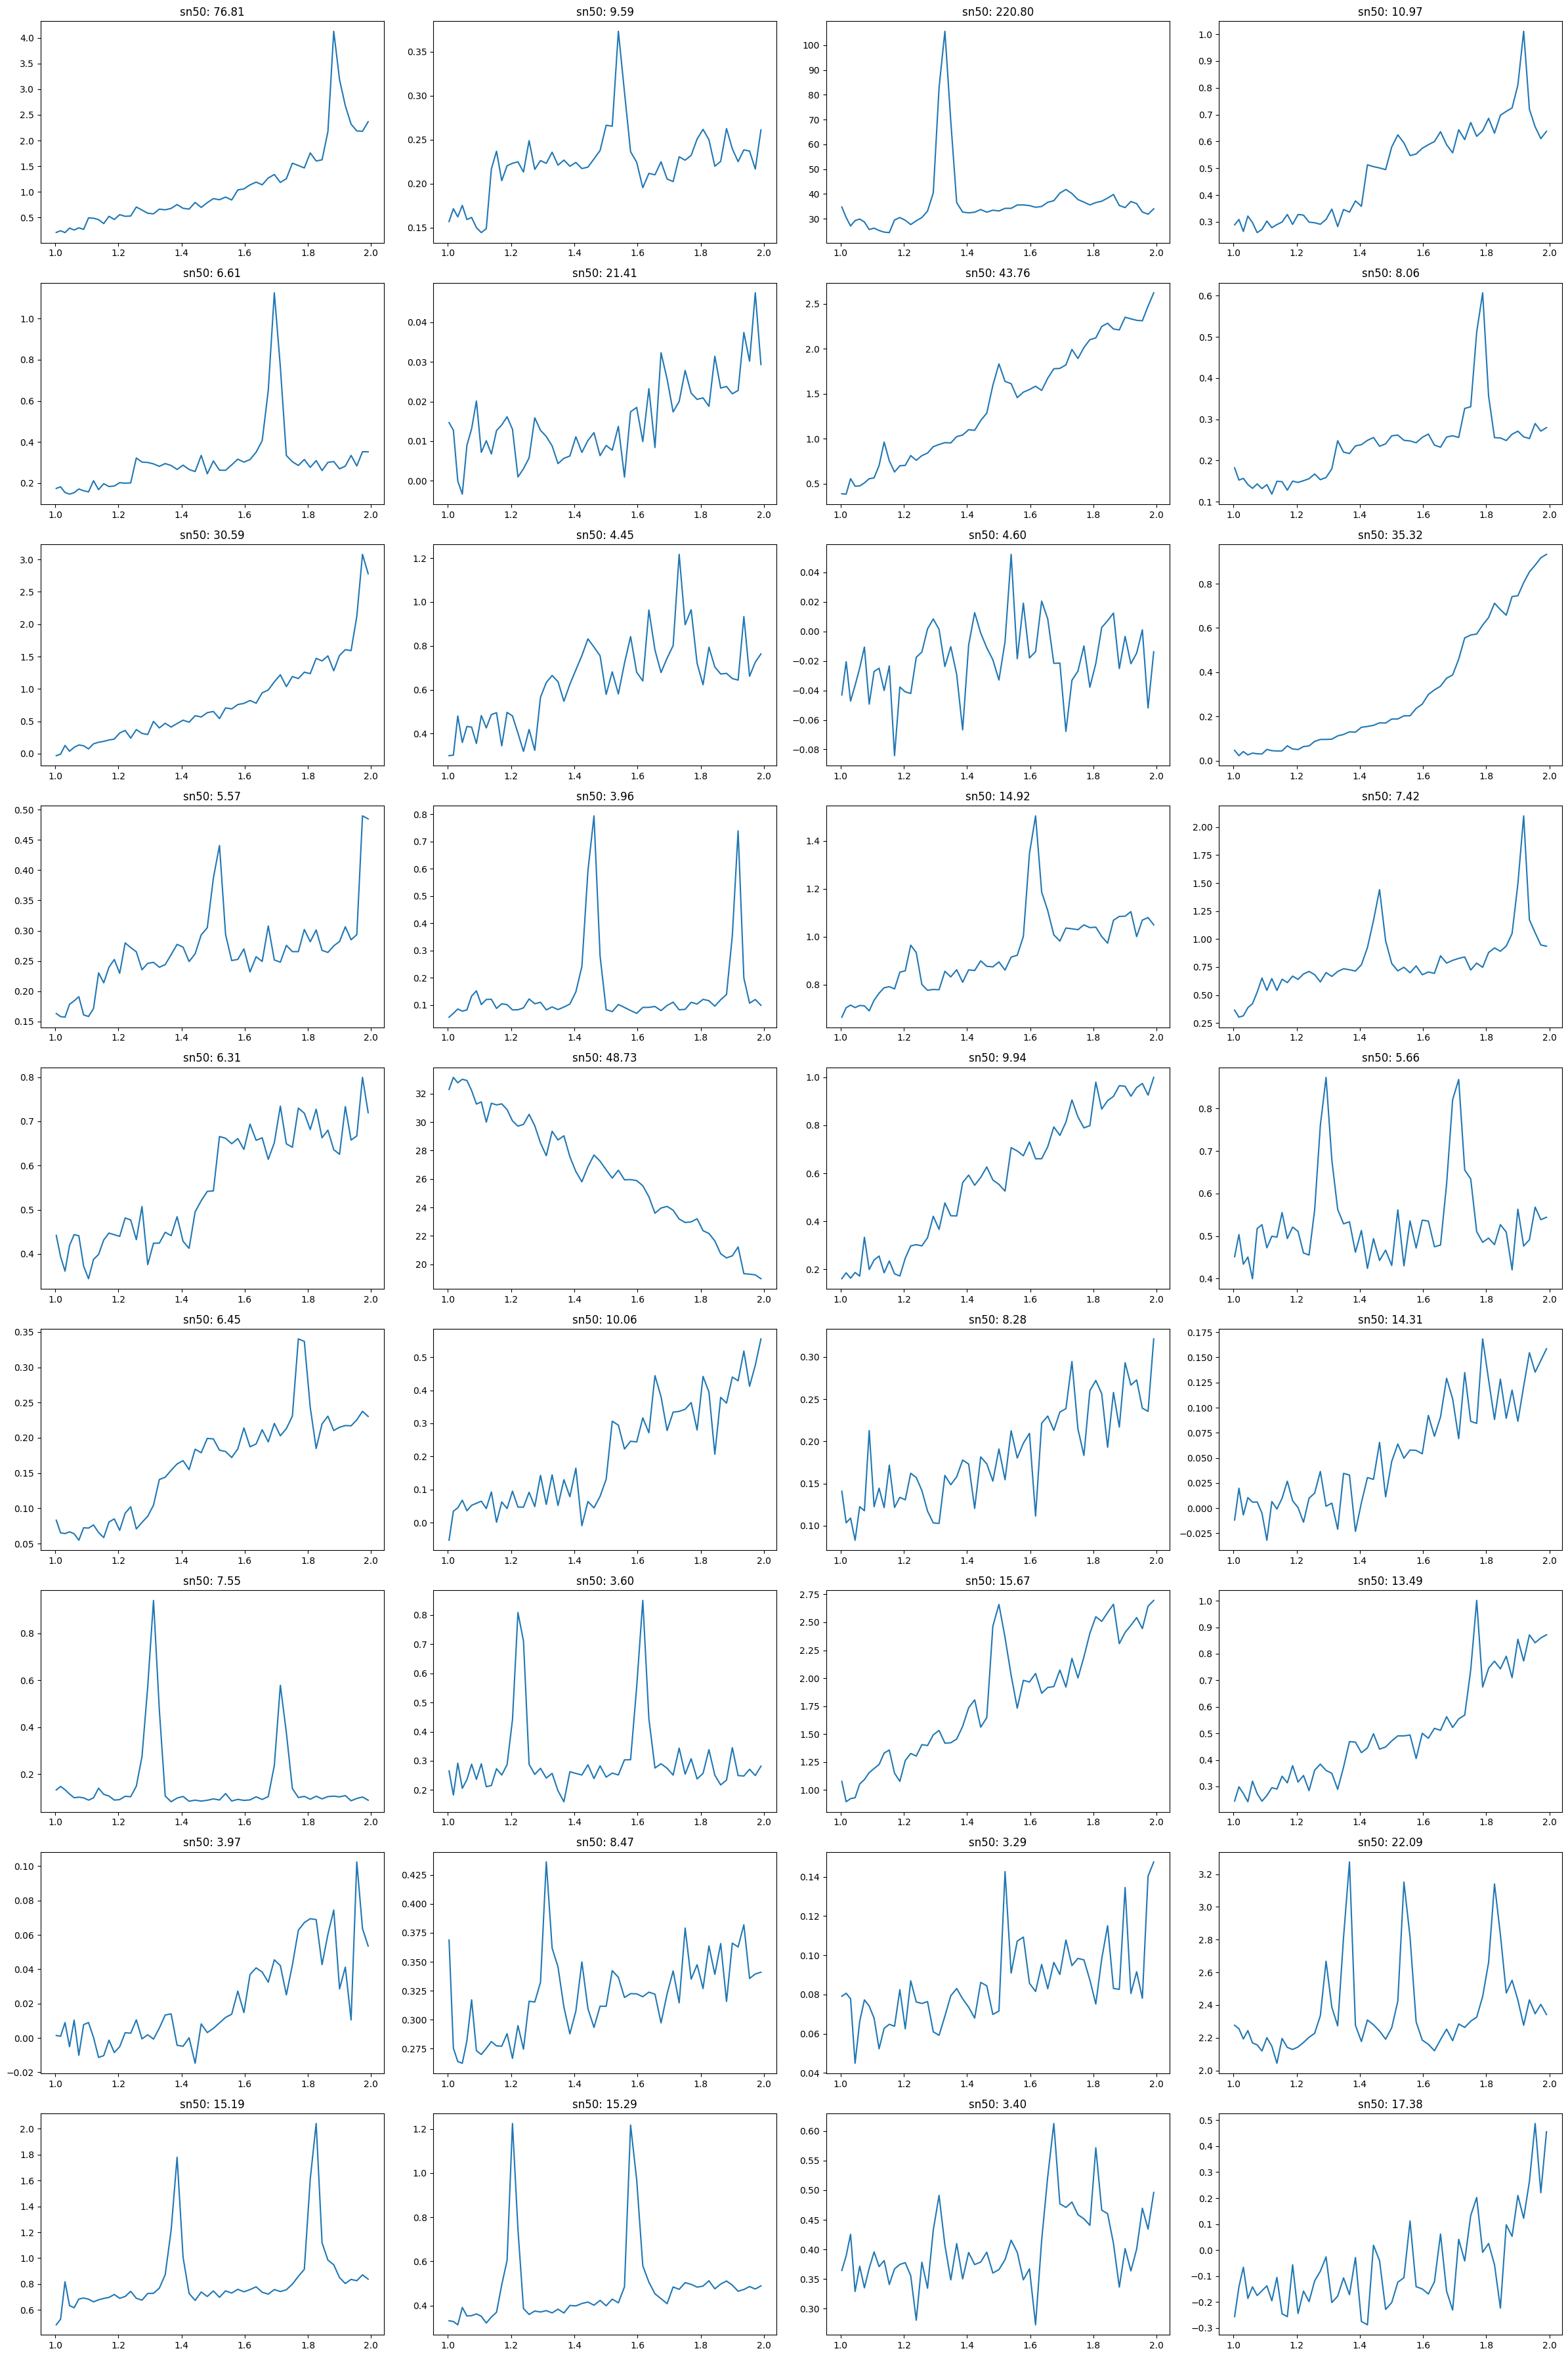

Resolution: mid, shape of flux: (4088, 1666), number of spectra: 4088, wavelength range: 1.000599980354309 - 1.9996000528335571


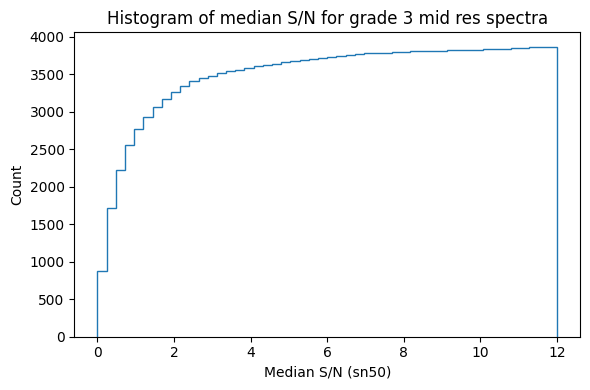

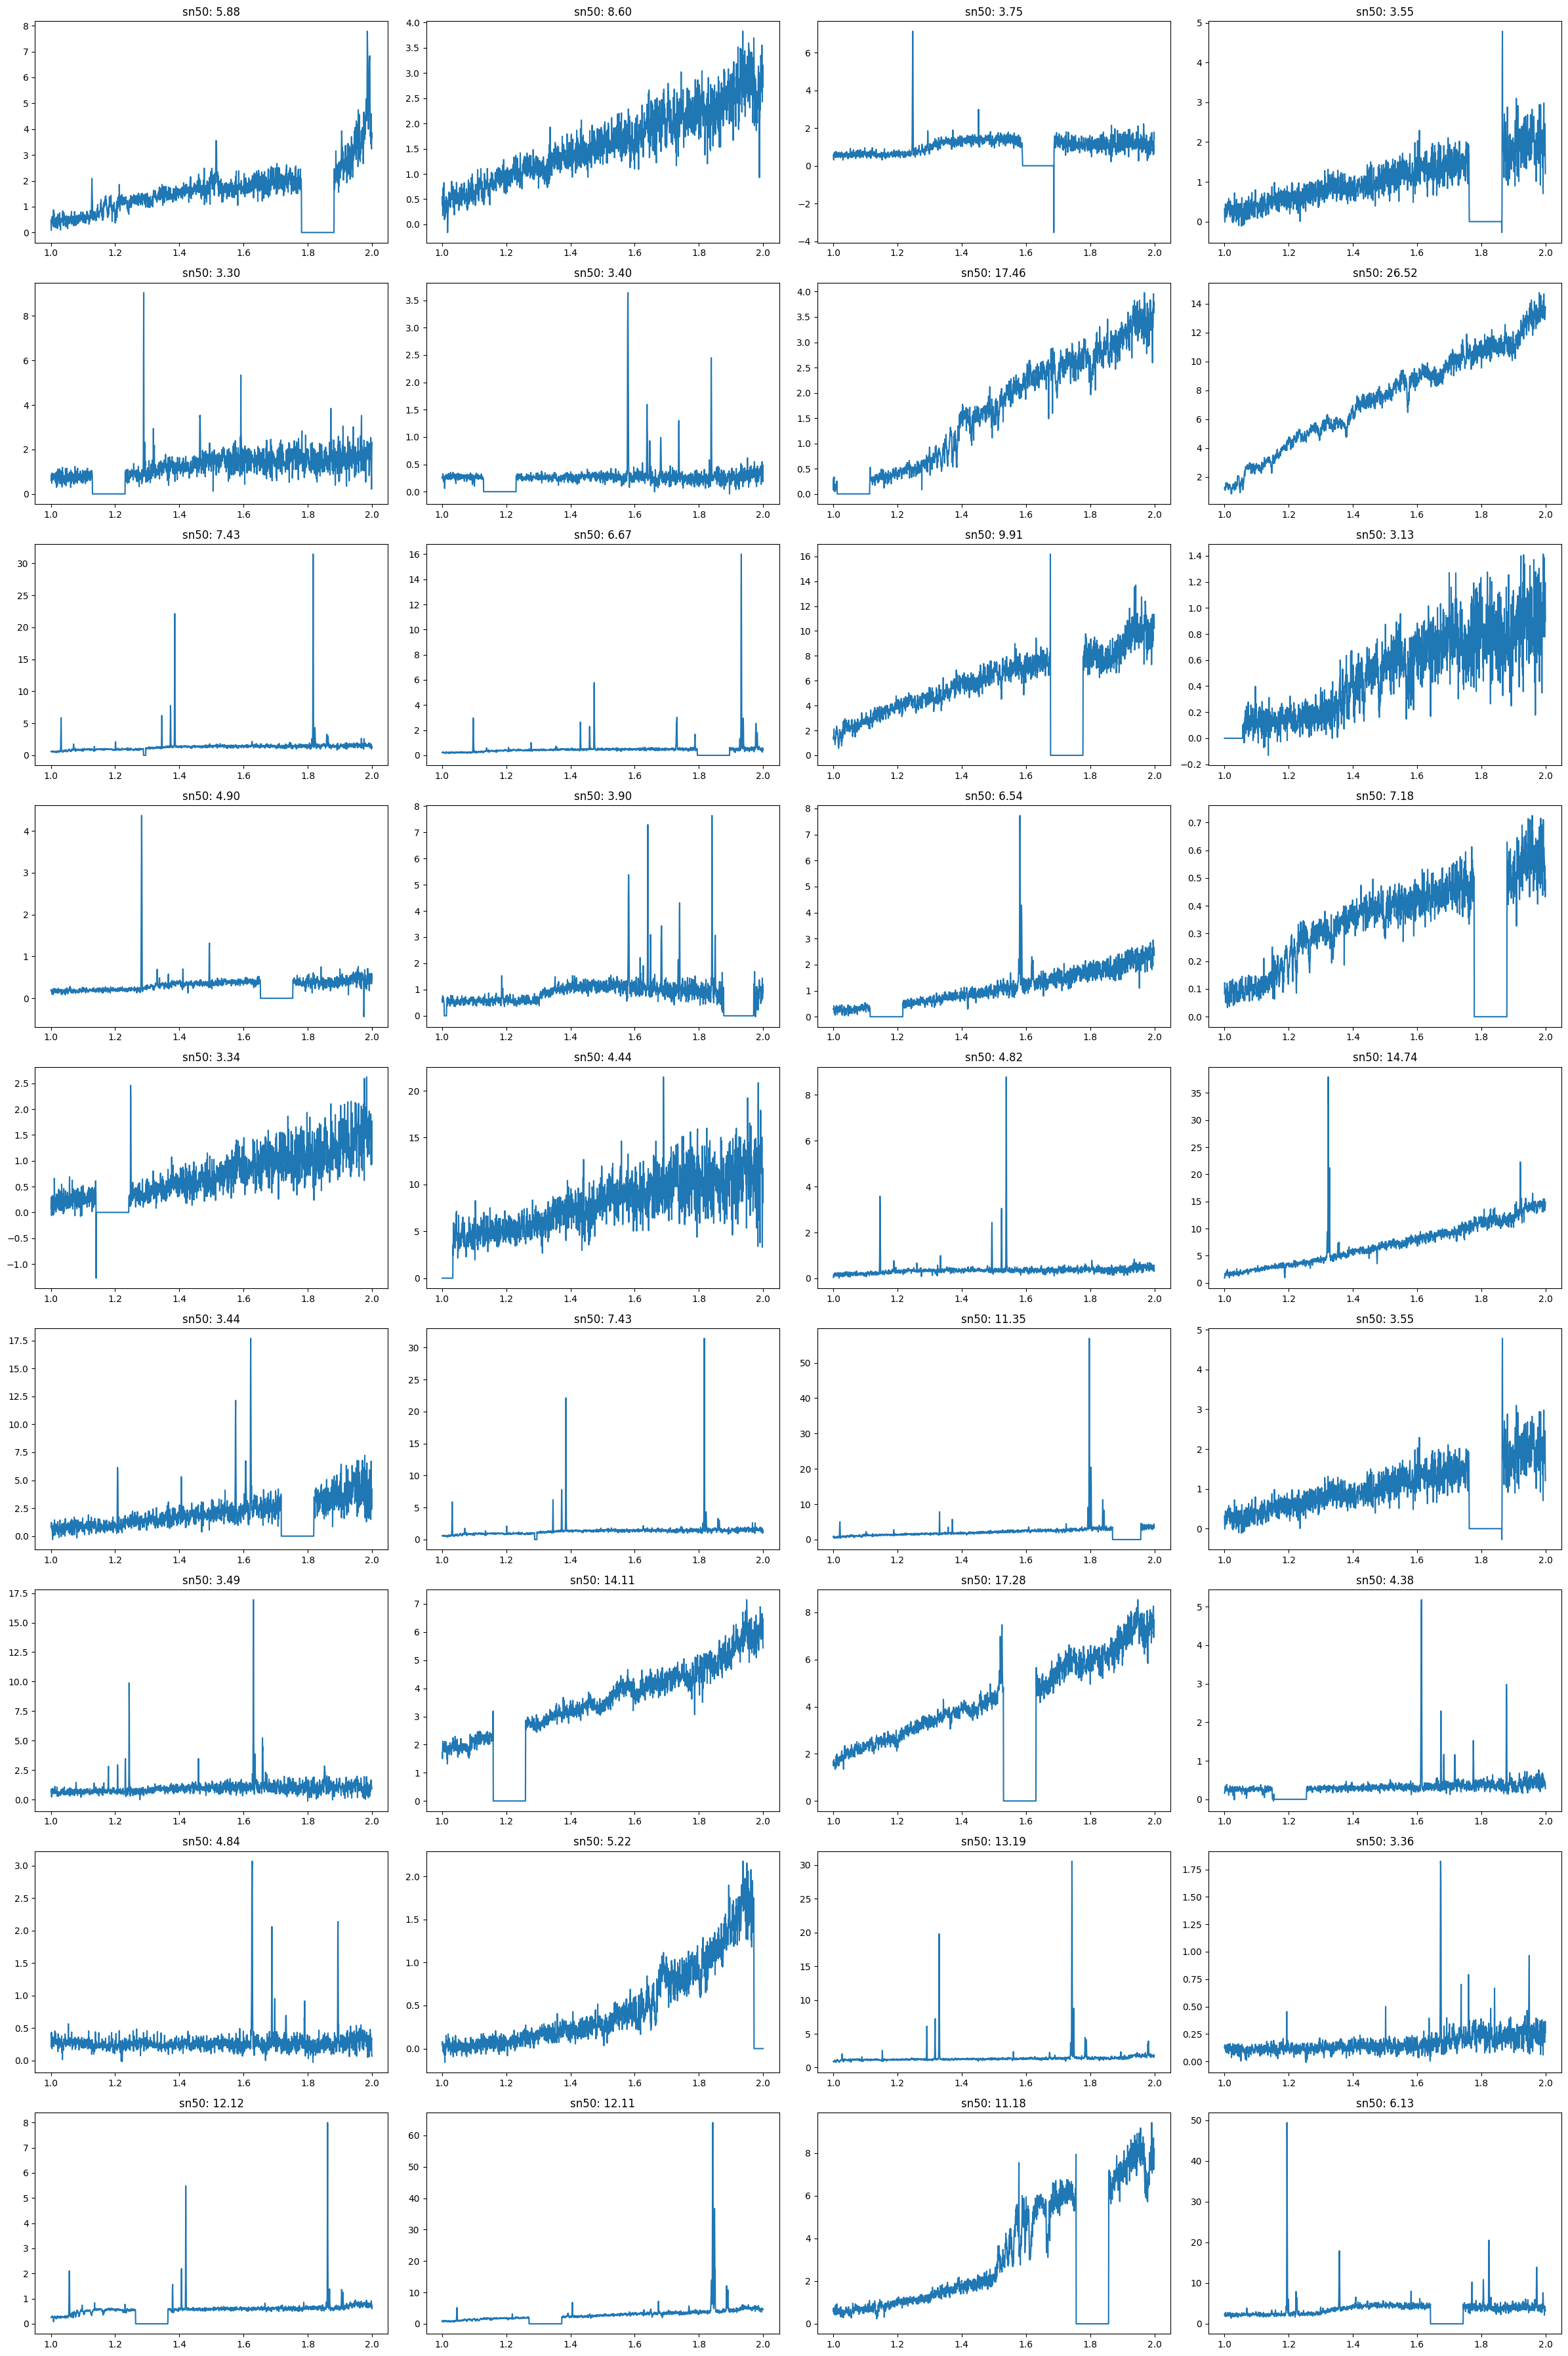

Resolution: high, shape of flux: (124, 3971), number of spectra: 124, wavelength range: 1.0000532865524292 - 1.8999199867248535


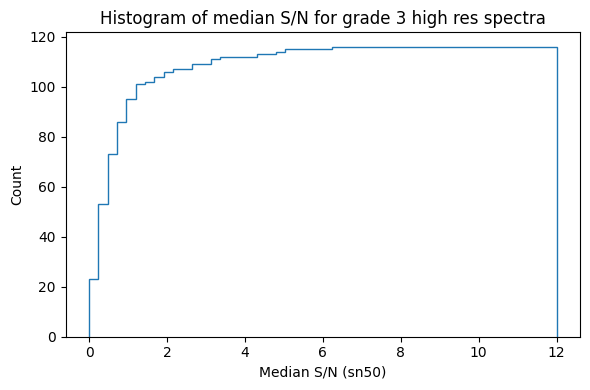

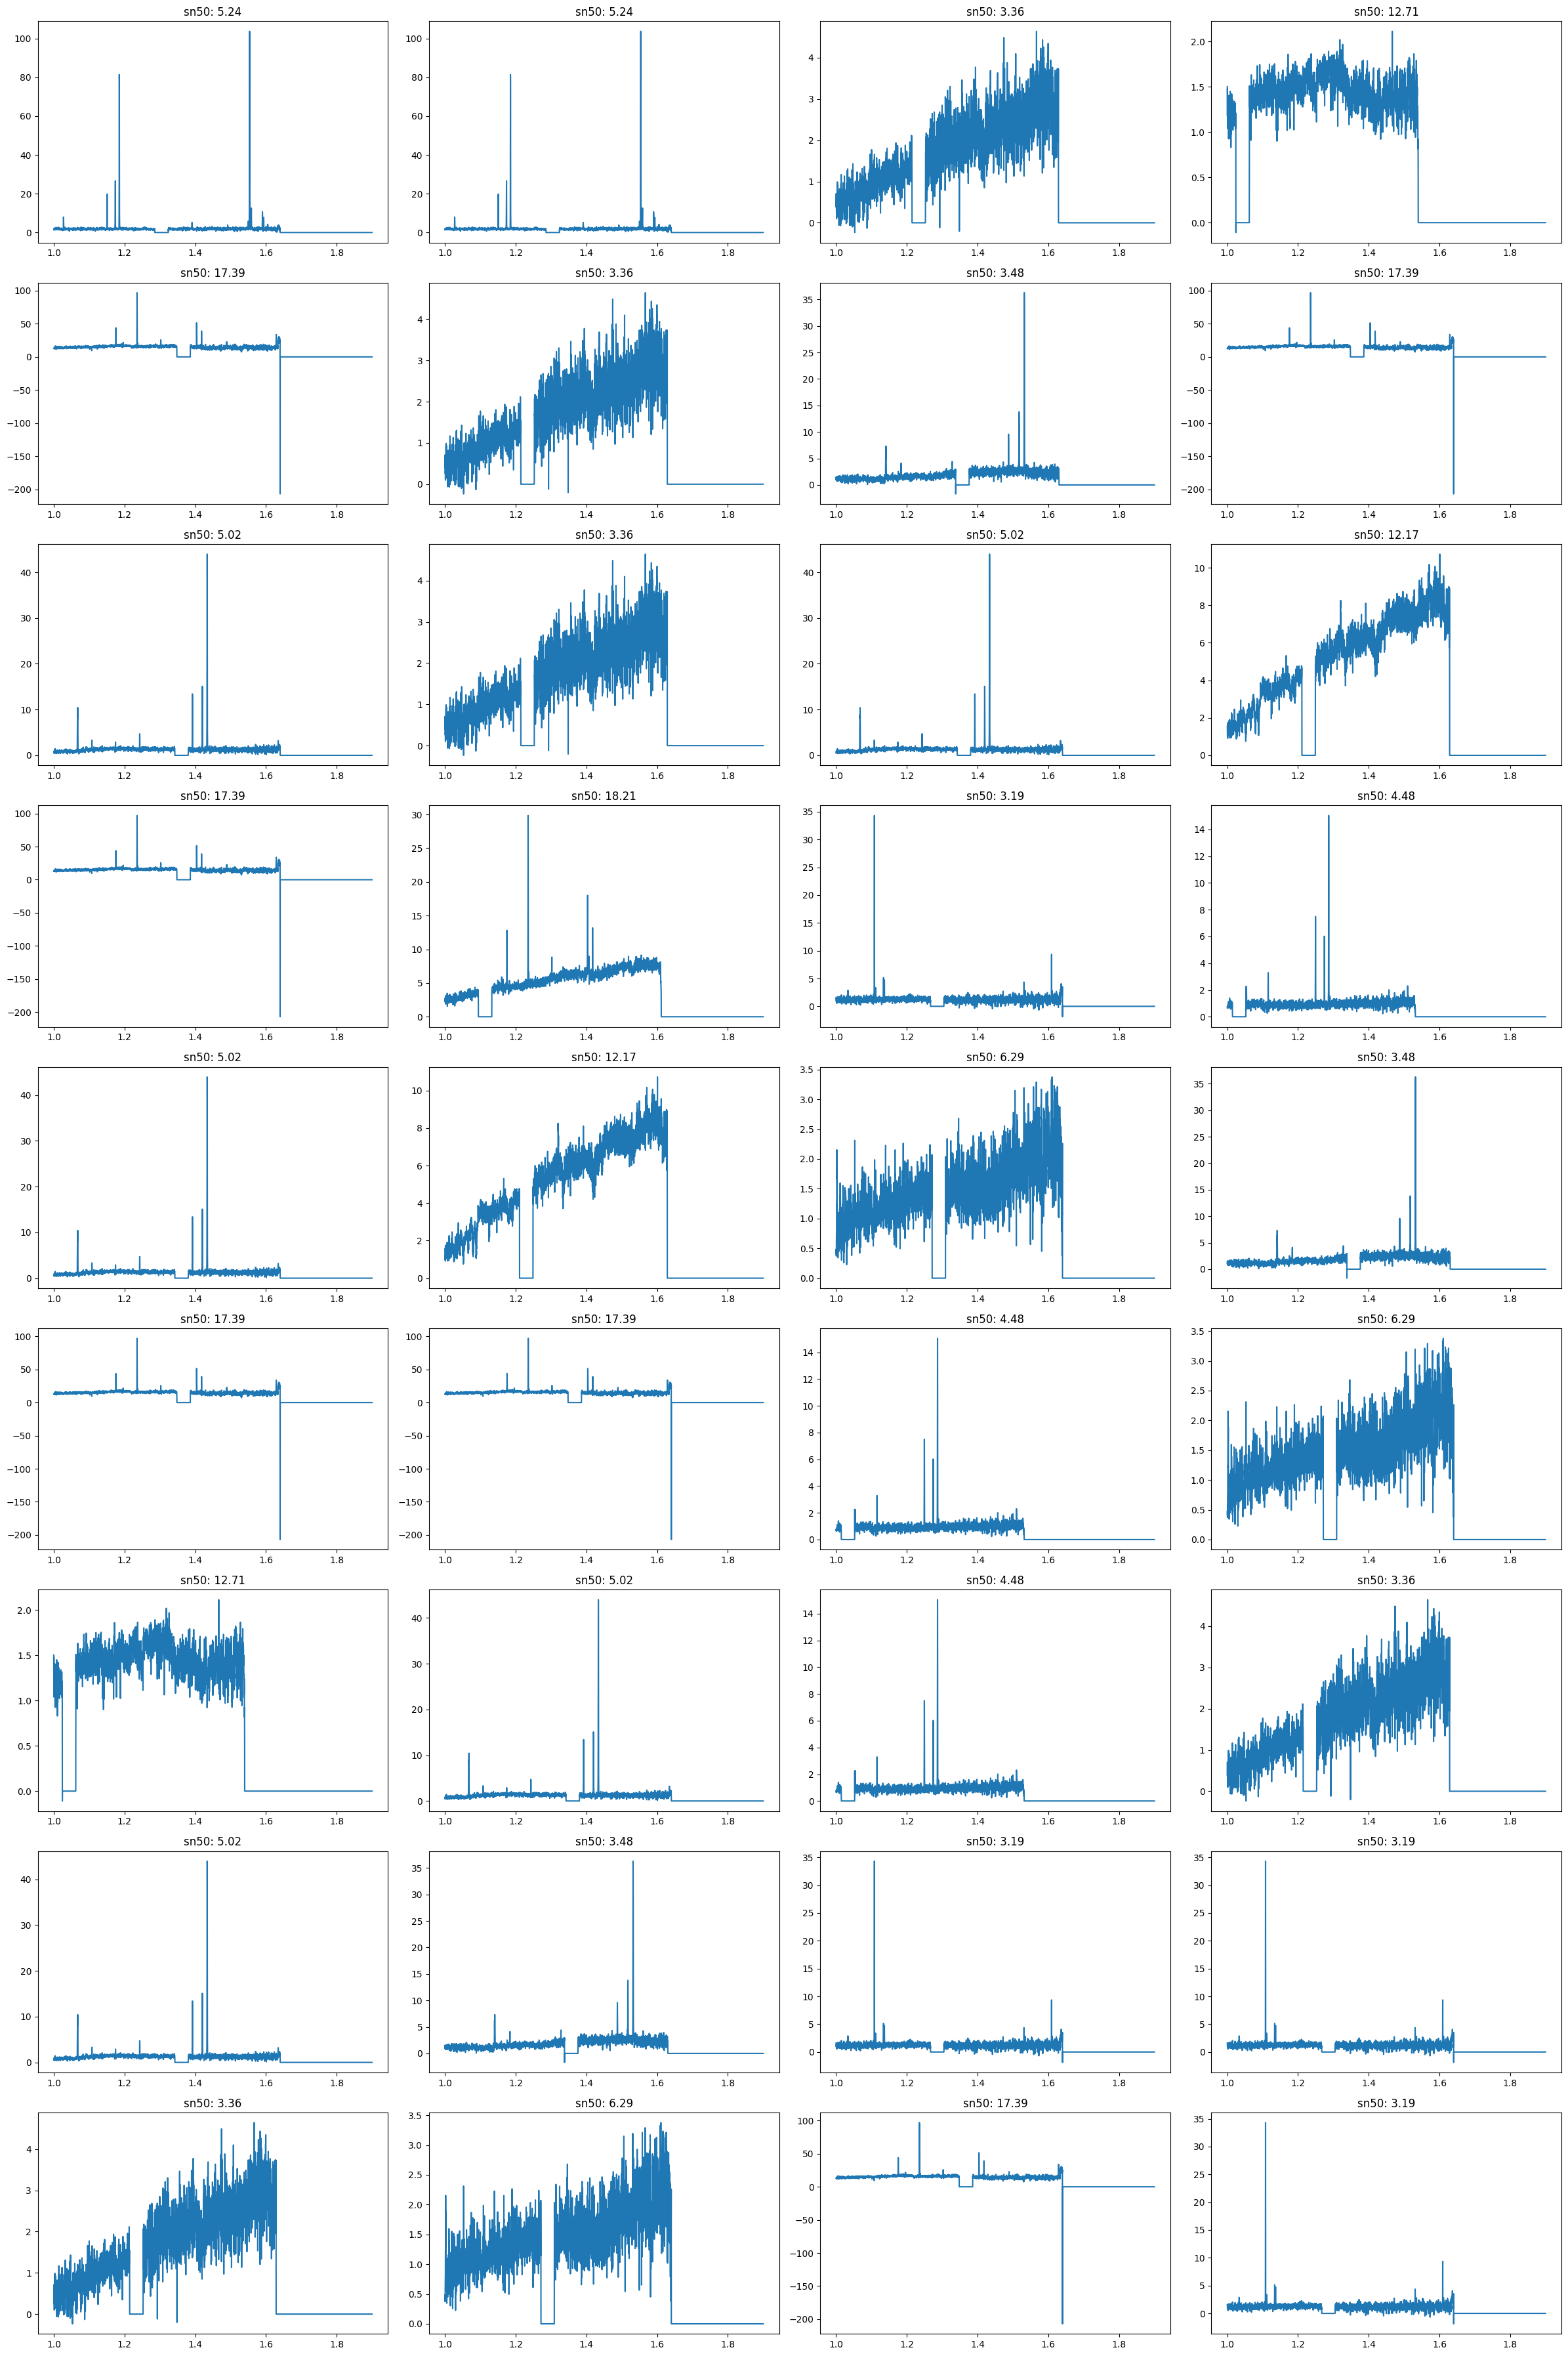

In [26]:
#plot same example plots with grade 3
for res in ["low", "mid", "high"]:
    with h5py.File(f"jda_spectra_{res}.h5", "r") as f:
        print(f"Resolution: {res}, shape of flux: {f['flux'].shape}, number of spectra: {len(f['flux'])}, wavelength range: {f['wave'][0][0]} - {f['wave'][0][-1]}")
        #filter out exazmple spectra with sn50 < 5 and grade == 3
        mask_sn = f["sn50"][:] >= 3
        mask_grade = f["grade"][:] == 3
        mask = mask_sn & mask_grade
        #random n sample index
        idx = np.random.choice(np.where(mask)[0], n_sample)
        
        #plot sn cumulative histogram
        plt.figure(figsize=(6,4))
        plt.hist(f["sn50"][:], bins=50, histtype="step", color="C0", range=(0, 12), cumulative=True, density=False)
        plt.xlabel("Median S/N (sn50)")
        plt.ylabel("Count")
        plt.title(f"Histogram of median S/N for grade 3 {res} res spectra")
        plt.tight_layout()
        plt.show()
        
        #4 columns of subplots
        rows = (n_sample + 3) // 4
        fig, axes = plt.subplots(rows, 4, figsize=(24, 4*rows))
        for i, index in enumerate(idx):
            ax = axes.flatten()[i]
            wave = f["wave"][index]
            flux = f["flux"][index]
            ax.plot(wave, flux)
            ax.set_title(f"sn50: {f['sn50'][index]:.2f}")
        plt.tight_layout()
        plt.show()

In [59]:
from astropy.io import fits
sample_rows = df[mask].head(-1).sample(n=500)
for row in tqdm(df[mask].head(100).itertuples()):
    spec_file = f"{download_dir}/{row.file}"
    #if spec_file has multiple entries, get the object
    try:
        with fits.open(spec_file) as hdul:
            table = Table.read(hdul[1])  # Read the second HDU (the spectrum table)
            #unit of flux
            if table['flux'].unit != 'uJy':
                print(f"{row.file} has flux unit {table['flux'].unit}")
    except Exception as e:
        print(f"Failed to read {spec_file}: {e}")

0it [00:00, ?it/s]

Total spectra : 21670
Unique lengths: 3
  Length     Count  Fraction
      56     20509     94.6%
    1666      1082      5.0%
    3971        79      0.4%


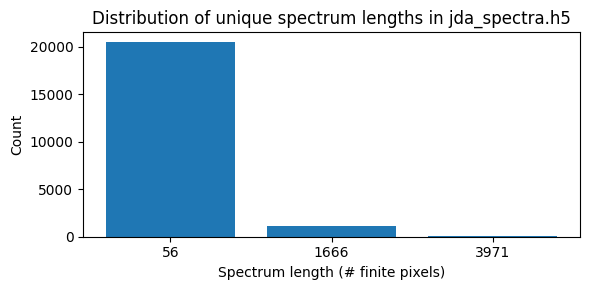

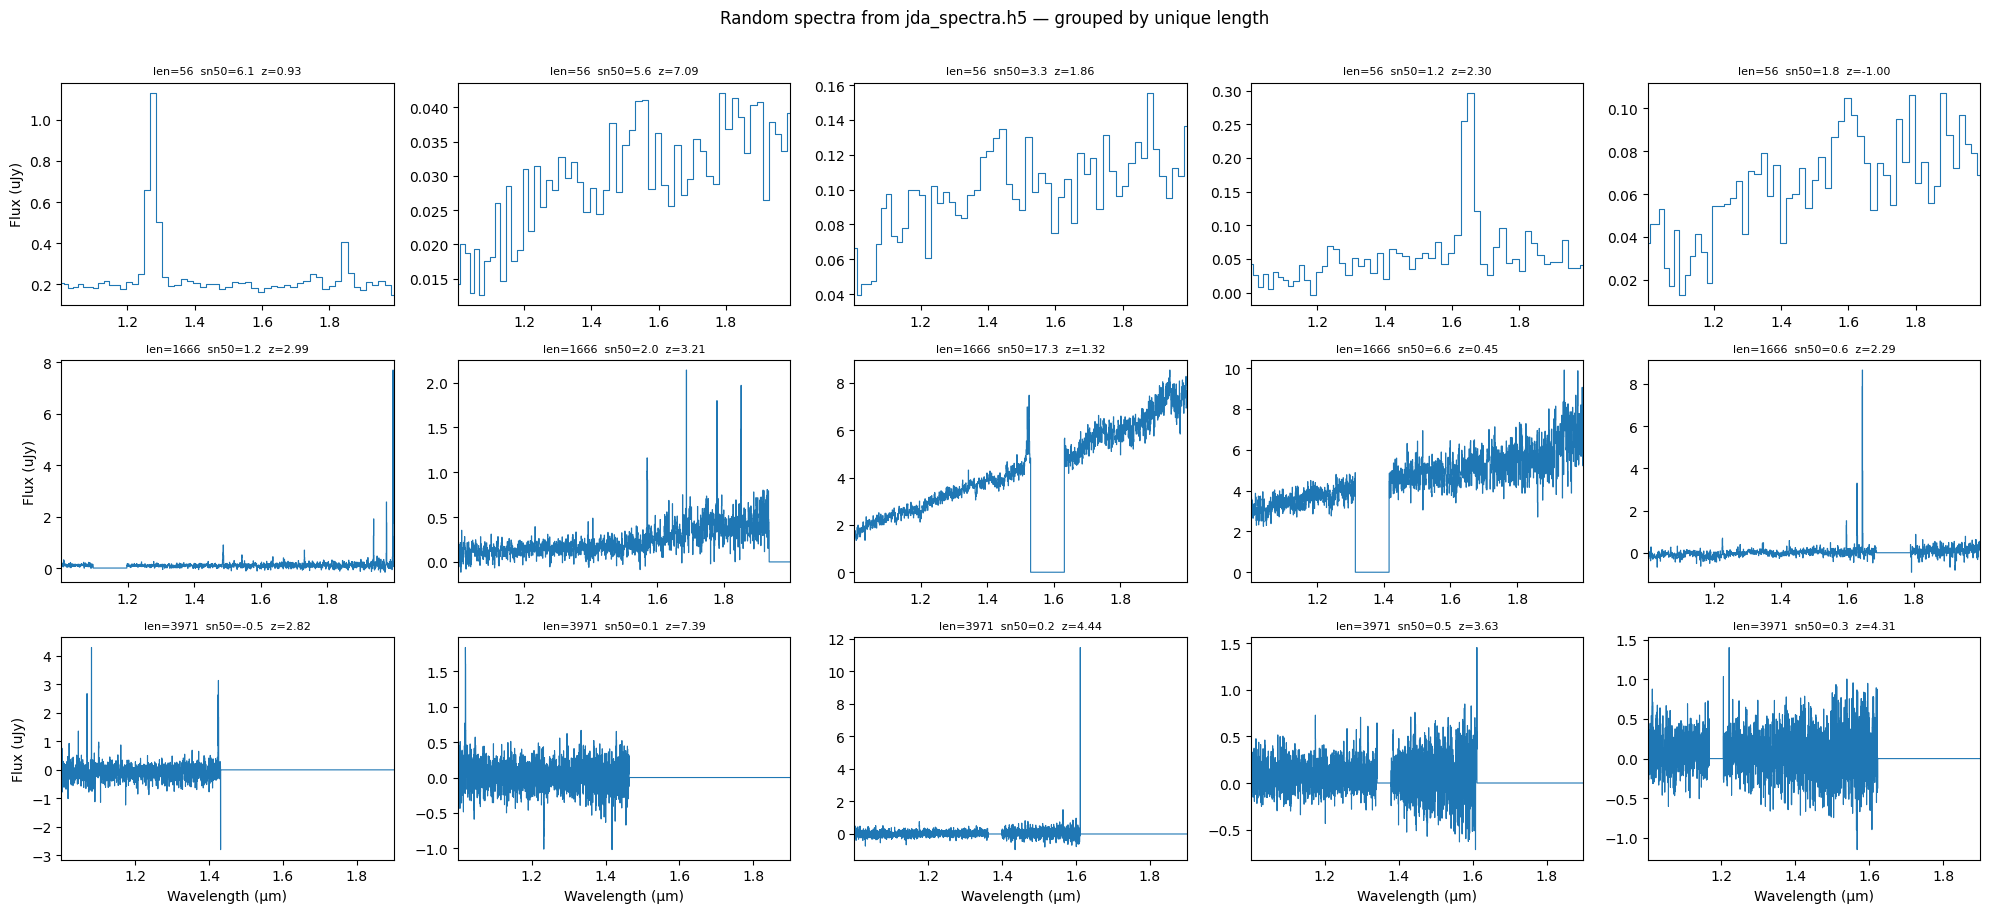

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

H5_PATH = "jda_spectra.h5"

with h5py.File(H5_PATH, "r") as h5:
    wave_all = h5["wave"][:]   # (N, L)
    flux_all = h5["flux"][:]   # (N, L)
    sn50_all = h5["sn50"][:]
    z_all    = h5["z_best"][:]
    N        = wave_all.shape[0]

# ── 1. Unique spectrum lengths ────────────────────────────────────────────────
# "Length" = number of finite (non-NaN) wavelength pixels per object
lengths = np.sum(np.isfinite(wave_all), axis=1)
unique_lens, counts = np.unique(lengths, return_counts=True)

print(f"Total spectra : {N}")
print(f"Unique lengths: {len(unique_lens)}")
print(f"{'Length':>8}  {'Count':>8}  {'Fraction':>8}")
for l, c in zip(unique_lens, counts):
    print(f"{l:>8d}  {c:>8d}  {c/N:>8.1%}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(len(unique_lens)), counts, tick_label=[str(l) for l in unique_lens])
ax.set_xlabel("Spectrum length (# finite pixels)")
ax.set_ylabel("Count")
ax.set_title("Distribution of unique spectrum lengths in jda_spectra.h5")
plt.tight_layout()
plt.show()

# ── 2. Random examples — one panel per unique length group ────────────────────
n_per_group = 5
n_cols = n_per_group
n_rows = len(unique_lens)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols, 3 * n_rows),
                         squeeze=False)

rng = np.random.default_rng(42)

for row_i, (spec_len, cnt) in enumerate(zip(unique_lens, counts)):
    group_idx = np.where(lengths == spec_len)[0]
    chosen    = rng.choice(group_idx, size=min(n_per_group, len(group_idx)))

    for col_i in range(n_cols):
        ax = axes[row_i, col_i]
        if col_i < len(chosen):
            i = chosen[col_i]
            w = wave_all[i]
            f = flux_all[i]
            valid = np.isfinite(w)
            ax.plot(w[valid], f[valid], drawstyle="steps-mid", lw=0.8)
            ax.set_title(f"len={spec_len}  sn50={sn50_all[i]:.1f}  z={z_all[i]:.2f}",
                         fontsize=8)
            ax.set_xlim(w[valid].min(), w[valid].max())
        else:
            ax.axis("off")
        if col_i == 0:
            ax.set_ylabel("Flux (uJy)")
        if row_i == n_rows - 1:
            ax.set_xlabel("Wavelength (µm)")

fig.suptitle("Random spectra from jda_spectra.h5 — grouped by unique length", y=1.01)
plt.tight_layout()
plt.show()


In [1]:
from h5py import File

h5file = File("jda_spectra.h5", "r")
print("Keys in HDF5 file:", list(h5file.keys()))
#check  wave, flux
for key in ["wave", "flux"]:    
    print(f"{key} shape: {h5file[key].shape}, dtype: {h5file[key].dtype}")

Keys in HDF5 file: ['dec', 'flux', 'objid', 'phot_f150w_tot_1', 'ra', 'sn50', 'srcid', 'wave', 'z_best']
wave shape: (21670, 3971), dtype: float32
flux shape: (21670, 3971), dtype: float32
